# Unit 7: Linear Regression Models
 
updated on 5/25/2025

In [23]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

## Part 1: Simple linear regression

### Demo 7-1 simple linear regression

In [24]:
data=pd.read_csv("mtcars.csv")

In [25]:
data.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


<Axes: xlabel='wt', ylabel='mpg'>

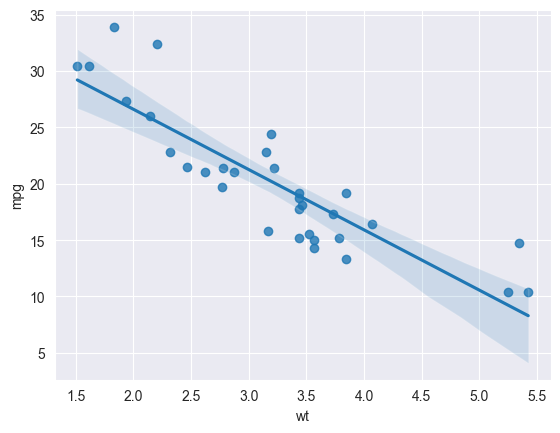

In [26]:
sns.regplot(y="mpg",x="wt",data=data)

#### 7-1a:  scipy.stats.linregress

输出：
-------
result : ``LinregressResult`` instance
    The return value is an object with the following attributes:

    slope （斜率，b1）: float
        Slope of the regression line.
    intercept （截距，b0）: float
        Intercept of the regression line.
    rvalue （相关系数）: float
        The Pearson correlation coefficient. The square of ``rvalue``
        is equal to the coefficient of determination.
    pvalue （斜率b1的显著性 vs 0）: float
        The p-value for a hypothesis test whose null hypothesis is
        that the slope is zero, using Wald Test with t-distribution of
        the test statistic. See `alternative` above for alternative
        hypotheses.
    stderr （b1的标准误差） : float
        Standard error of the estimated slope (gradient), under the
        assumption of residual normality.
    intercept_stderr （b0的标准误差） : float
        Standard error of the estimated intercept, under the assumption
        of residual normality.



In [27]:
LR=stats.linregress(data.mpg,data.hp)

In [28]:
print(LR)

LinregressResult(slope=np.float64(-8.829730992068217), intercept=np.float64(324.08231421252054), rvalue=np.float64(-0.7761683718265865), pvalue=np.float64(1.787835254121062e-07), stderr=np.float64(1.3095850136995284), intercept_stderr=np.float64(27.433295753991796))


#### 7-1b: statsmodels.formula.api.ols

In [29]:
import statsmodels.formula.api as smf

In [42]:
model = smf.ols('mpg~wt', data=data)
results = model.fit()
#print(results.params)
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     91.38
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.29e-10
Time:                        10:23:17   Log-Likelihood:                -80.015
No. Observations:                  32   AIC:                             164.0
Df Residuals:                      30   BIC:                             167.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.2851      1.878     19.858      0.0

### 7-2: mutiple linear regression

In [31]:
data=pd.read_csv("mtcars.csv")

In [32]:
data.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


#### Demo 7-2a smf.ols

#### Plotting the data, showing the correlations

<Axes: xlabel='hp', ylabel='wt'>

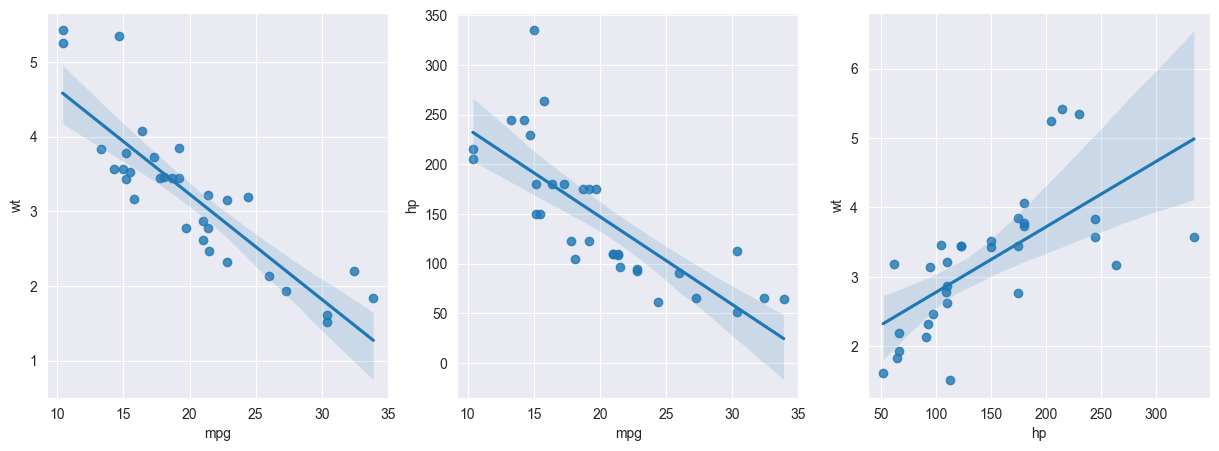

In [33]:
sns.set_style("darkgrid")
fig,ax=plt.subplots(1,3,figsize=(15,5))
sns.regplot(x="mpg",y="wt",data=data,ax=ax[0])
sns.regplot(x="mpg",y="hp",data=data,ax=ax[1])
sns.regplot(x="hp",y="wt",data=data,ax=ax[2])


#### OLS model
1. import statsmodels.formula.api as smf
2. smf.ols
\\
该函数输出结果是一个模型model，然后利用model.fit()函数完成模型估计，输出得结果results包含了全部模型信息。 
- results.summary(): 全部模型信息，模型参数估计，模型残差
- 可以用results.resid， results.fittedvalues来获得模型得残差，模型预测值等等，也可以画出残差图。 

In [34]:
model = smf.ols('mpg~hp', data=data)
results = model.fit()
#print(results.params)
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.589
Method:                 Least Squares   F-statistic:                     45.46
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.79e-07
Time:                        10:20:08   Log-Likelihood:                -87.619
No. Observations:                  32   AIC:                             179.2
Df Residuals:                      30   BIC:                             182.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.0989      1.634     18.421      0.0

### 残差可视化：  Showing the residuals vs fitted values plot , 检查正态性，方差齐性等。  

<Axes: xlabel='None', ylabel='None'>

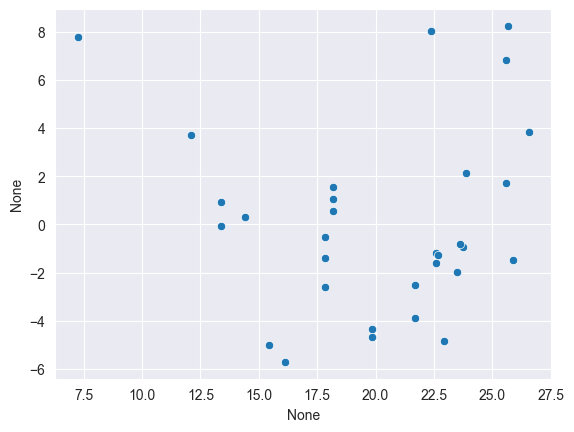

In [35]:
residuals = results.resid
fitted_value = results.fittedvalues
sns.scatterplot(x=fitted_value,y=residuals)

## Demo 7:  MLR模型建立和评价演示+作业（MLR, 2 points）

### Demo of CIB and PIB


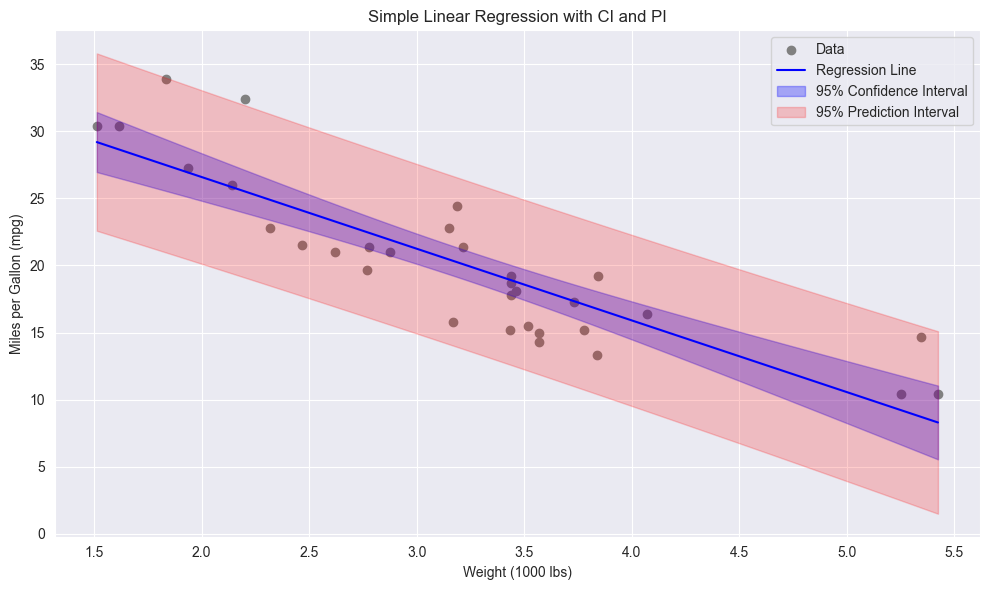

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 加载 mtcars 数据（需要从 R 中复制或使用等效数据）
# 这里我们使用 seaborn 的 mpg 数据替代，或你可直接加载 mtcars 数据。
import statsmodels.datasets
mtcars = pd.read_csv("mtcars.csv")

# 设置自变量和因变量
x = mtcars["wt"]  # 汽车重量
y = mtcars["mpg"]  # 英里每加仑

# 添加常数项用于回归
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

# 生成预测值与置信区间
x_pred = np.linspace(x.min(), x.max(), 100)
X_pred = sm.add_constant(x_pred)
predictions = model.get_prediction(X_pred)
summary_frame = predictions.summary_frame(alpha=0.05)

# 绘图
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label="Data", color='gray')

# 画回归线
plt.plot(x_pred, summary_frame['mean'], label='Regression Line', color='blue')

# 画置信区间
plt.fill_between(x_pred, 
                 summary_frame['mean_ci_lower'], 
                 summary_frame['mean_ci_upper'], 
                 color='blue', alpha=0.3, label='95% Confidence Interval')

# 画预测区间
plt.fill_between(x_pred, 
                 summary_frame['obs_ci_lower'], 
                 summary_frame['obs_ci_upper'], 
                 color='red', alpha=0.2, label='95% Prediction Interval')

plt.xlabel("Weight (1000 lbs)")
plt.ylabel("Miles per Gallon (mpg)")
plt.title("Simple Linear Regression with CI and PI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Demo 7-1: mtcars

In [37]:
data=pd.read_csv("mtcars.csv")

In [38]:
data.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


### 任务
对mtcars.csv数据

* sns.pairplot
* 如果把mpg （mile per galon ,每加仑汽油的公里数，反映油耗） 作为因变量， 适用smf.ols建立一个线性模型。 
* 分别从模型的解释性，预测性评价建立的模型



In [39]:
model = smf.ols('mpg~wt+hp+hp*wt+qsec+gear+disp', data=data)
results = model.fit()
#print(results.params)
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     39.33
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.50e-11
Time:                        10:20:09   Log-Likelihood:                -64.849
No. Observations:                  32   AIC:                             143.7
Df Residuals:                      25   BIC:                             154.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.8742      9.663      3.091      0.0

<Axes: xlabel='None', ylabel='None'>

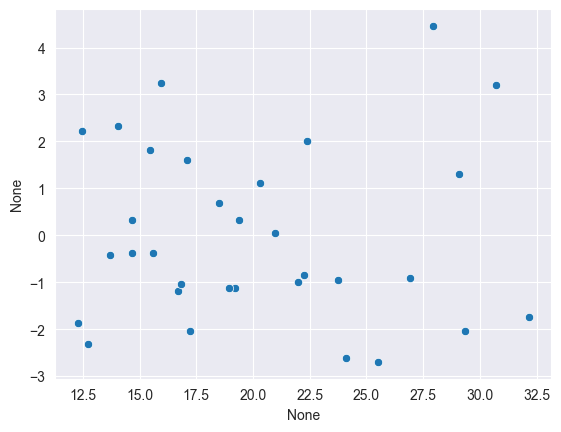

In [40]:
residuals = results.resid
fitted_value = results.fittedvalues
sns.scatterplot(x=fitted_value,y=residuals)

### 练习作业 1 （insurance.csv） （Group 1）

In [41]:
data1=pd.read_csv("insurance.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'insurance.csv'

In [ ]:
data1.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### 任务

1. 数据可视化 ， 把charges（保费） 作为因变量（y-axis)
* sns.pairplot ： bmi, charges,age
* sns.scatterplot:  children
* sns.boxplot: 分别针对region, smoker， sex, 

2. 以charges（保费） 作为自变量，尝试用线性模型尽可能地预测charges，并避免过拟合问题。并根据本周课程学习的方法分别从**解释性和预测性**来评价模型

    * Adj. R-squared 不减小 
    * AIC (最小）
    * 残差分析：
        * 残差可视化
        * 正态性
        * 齐性 (Durbin-Watson) 
        * 变量共线性 （Cond. No)



In [ ]:
model = smf.ols('###', data=data1)
results = model.fit()
#print(results.params)
print(results.summary())

PatsyError: comments are not allowed
    ###
    ^^^

In [ ]:
## 残差可视化
residuals = results.resid
fitted_value = results.fittedvalues
sns.scatterplot(x=fitted_value,y=residuals)

### 练习作业 -2（Student Performance） （Group 2)

In [ ]:
data2=pd.read_csv("Student_Performance.csv")

In [ ]:
data2.head()

,HoursStudied,PreviousScores,ExtracurricularActivities,SleepHours,SampleQuestionPapersPracticed,PerformanceIndex
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [ ]:
data2.shape

(10000, 6)

### 任务

1. 数据可视化 ， 把PerformanceIndex（学生成绩） 作为因变量（y-axis)
* sns.pairplot ：HoursStudied, PreviousScores, SleepHours
* sns.scatterplot:  SampleQuestionPapersPracticed
* sns.boxplot: 分别针对ExtracurricularActivities, 

2. 以PerformanceIndex（学生成绩） 作为自变量，尝试用线性模型尽可能地预测PerformanceIndex，并避免过拟合问题。并根据本周课程学习的方法分别从**解释性和预测性**来评价模型评价模型

    * Adj. R-squared 不减小 
    * AIC (最小）
    * 残差分析：
        * 残差可视化
        * 正态性
        * 齐性 (Durbin-Watson) 
        * 变量共线性 （Cond. No)

In [ ]:
data2.head()

,HoursStudied,PreviousScores,Extracurricular Activities,SleepHours,SampleQuestionPapersPracticed,PerformanceIndex
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [ ]:
model = smf.ols('####', data=data2)
results = model.fit()
#print(results.params)
print(results.summary())

PatsyError: comments are not allowed
    ####
    ^^^^

In [ ]:
## 残差可视化
residuals = results.resid
fitted_value = results.fittedvalues
sns.scatterplot(x=fitted_value,y=residuals)

In [ ]:
datax=pd.read_csv("LRData.csv")

### 补充演示：Simpson悖论数据演示

          x         y    group
0  0.496714 -0.956042  Group 1
1 -0.138264 -0.141191  Group 1
2  0.647689 -0.495202  Group 1
3  1.523030 -1.162654  Group 1
4 -0.234153  0.036434  Group 1


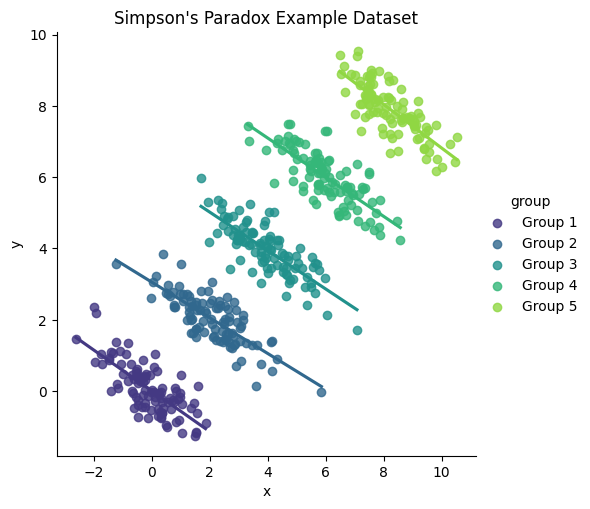

In [ ]:
# 产生数据集
import numpy as np
import pandas as pd

# 设置随机种子以确保可重复性
np.random.seed(42)

# 生成数据
def generate_data():
    data = pd.DataFrame()
    
    for group in range(5):  # 为每个类别生成数据
        # 生成随机数据
        x = np.random.normal(loc=group*2, scale=1.0, size=100)
        y = x * (-0.5) + np.random.normal(loc=group, scale=0.5, size=100)+group*2
        
        # 将数据添加到DataFrame
        df = pd.DataFrame({'x': x, 'y': y, 'group': f'Group {group+1}'})
        data = pd.concat([data, df], ignore_index=True)
    
    return data

# 生成并显示数据
data = generate_data()
print(data.head())

# 可以使用matplotlib或seaborn等库来可视化数据，以进一步探索Simpson's Paradox
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(x='x', y='y', hue='group', data=data, ci=None, palette='viridis')
plt.title('Simpson\'s Paradox Example Dataset')
plt.show()

In [ ]:
data.head()

,x,y,group
0,0.496714,-0.956042,Group 1
1,-0.138264,-0.141191,Group 1
2,0.647689,-0.495202,Group 1
3,1.523030,-1.162654,Group 1
4,-0.234153,0.036434,Group 1


In [ ]:
model = smf.ols('y~x', data=data)
results = model.fit()
#print(results.params)
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.724
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     1305.
Date:                Sun, 25 May 2025   Prob (F-statistic):          2.95e-141
Time:                        19:23:35   Log-Likelihood:                -914.94
No. Observations:                 500   AIC:                             1834.
Df Residuals:                     498   BIC:                             1842.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7992      0.111      7.189      0.0

<Axes: xlabel='None', ylabel='None'>

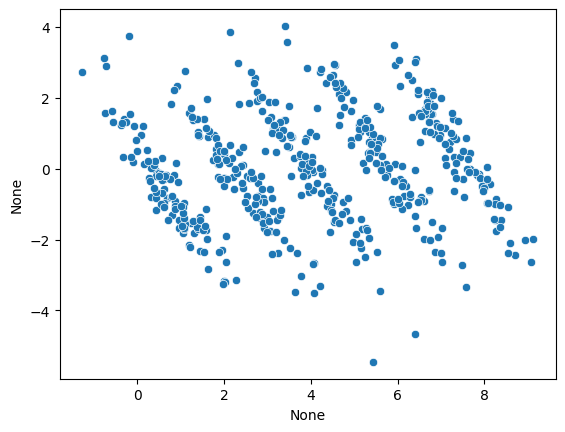

In [ ]:
## 残差可视化
residuals = results.resid
fitted_value = results.fittedvalues
sns.scatterplot(x=fitted_value,y=residuals)

In [ ]:
model = smf.ols('y~x+group', data=data)
results = model.fit()
#print(results.params)
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     3654.
Date:                Sun, 25 May 2025   Prob (F-statistic):               0.00
Time:                        19:23:59   Log-Likelihood:                -327.38
No. Observations:                 500   AIC:                             666.8
Df Residuals:                     494   BIC:                             692.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0060      0.047  

<Axes: xlabel='None', ylabel='None'>

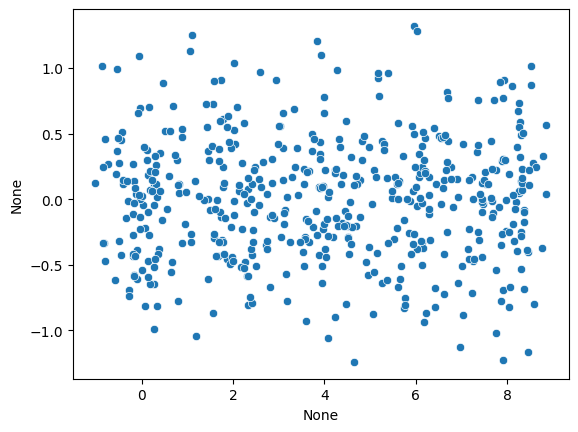

In [ ]:
## 残差可视化
residuals = results.resid
fitted_value = results.fittedvalues
sns.scatterplot(x=fitted_value,y=residuals)